# DFT, ReaxFF, MACE-medium, and MACE-polar comparison

This notebook uses only files contained in this folder. DFT values are raster-digitized. ReaxFF, MACE-medium, and MACE-polar values are calculated from terminal trajectory fragments; the new ReaxFF campaign uses the DFT paper's complete 42-case energy-orientation matrix and 2 ps endpoint.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / 'data').exists() and (ROOT.parent / 'data').exists():
    ROOT = ROOT.parent
if not (ROOT / 'data').exists():
    raise FileNotFoundError('Run this notebook from the repository root or notebooks directory.')

DATA = ROOT / 'data'
FIGURES = ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    # 'axes.spines.top': False,
    # 'axes.spines.right': False,
    'figure.dpi': 120,
})

## Load and standardize the mass spectra

The standardized table retains the source-specific probability definition and identifies whether each value is trajectory-derived or raster-digitized.

In [2]:
mace = pd.read_csv(DATA / 'processed' / 'mace_mass_spectra.csv')
dft = pd.read_csv(DATA / 'digitized' / 'dft_mass_spectrum_digitized.csv')
reaxff = pd.read_csv(DATA / 'processed' / 'reaxff_mass_spectrum.csv')

mace_std = mace.rename(columns={
    'model': 'method',
    'nominal_mass': 'mass_amu',
    'fragment_occurrence_probability': 'probability',
})[['method', 'energy_eV', 'mass_amu', 'probability']].copy()
mace_std['data_status'] = 'trajectory-derived'

dft_std = dft[['method', 'energy_eV', 'mass_amu', 'probability']].copy()
dft_std['data_status'] = 'raster-digitized visible bar'

reaxff_std = reaxff.rename(columns={
    'model': 'method',
    'nominal_mass': 'mass_amu',
    'fragment_occurrence_probability': 'probability',
})[['method', 'energy_eV', 'mass_amu', 'probability']].copy()
reaxff_std['method'] = 'ReaxFF'
reaxff_std['data_status'] = 'trajectory-derived, DFT-matched 42-case matrix'

spectra = pd.concat([dft_std, reaxff_std, mace_std], ignore_index=True)
spectra = spectra.sort_values(['method', 'energy_eV', 'mass_amu']).reset_index(drop=True)
spectra.to_csv(DATA / 'processed' / 'mass_spectra_standardized.csv', index=False)

coverage = (spectra.groupby(['method', 'energy_eV', 'data_status'])
            .size().rename('n_visible_or_detected_peaks').reset_index())
display(coverage)

,method,energy_eV,data_status,n_visible_or_detected_peaks
0,DFT-MD,10.0,raster-digitized visible bar,7
1,DFT-MD,20.0,raster-digitized visible bar,10
2,DFT-MD,30.0,raster-digitized visible bar,9
3,DFT-MD,40.0,raster-digitized visible bar,13
4,DFT-MD,50.0,raster-digitized visible bar,14
5,DFT-MD,75.0,raster-digitized visible bar,16
6,DFT-MD,100.0,raster-digitized visible bar,20
7,MACE-medium,10.0,trajectory-derived,2
8,MACE-medium,20.0,trajectory-derived,13
9,MACE-medium,30.0,trajectory-derived,12


## Matched-energy mass spectra

All seven energies use the same six incidence vectors and 2 ps endpoint for DFT and ReaxFF. Each row uses a common y scale. The interaction models remain different: DFT uses a frozen atomistic Au slab, while ReaxFF uses the source repository's continuum 12-6 wall.

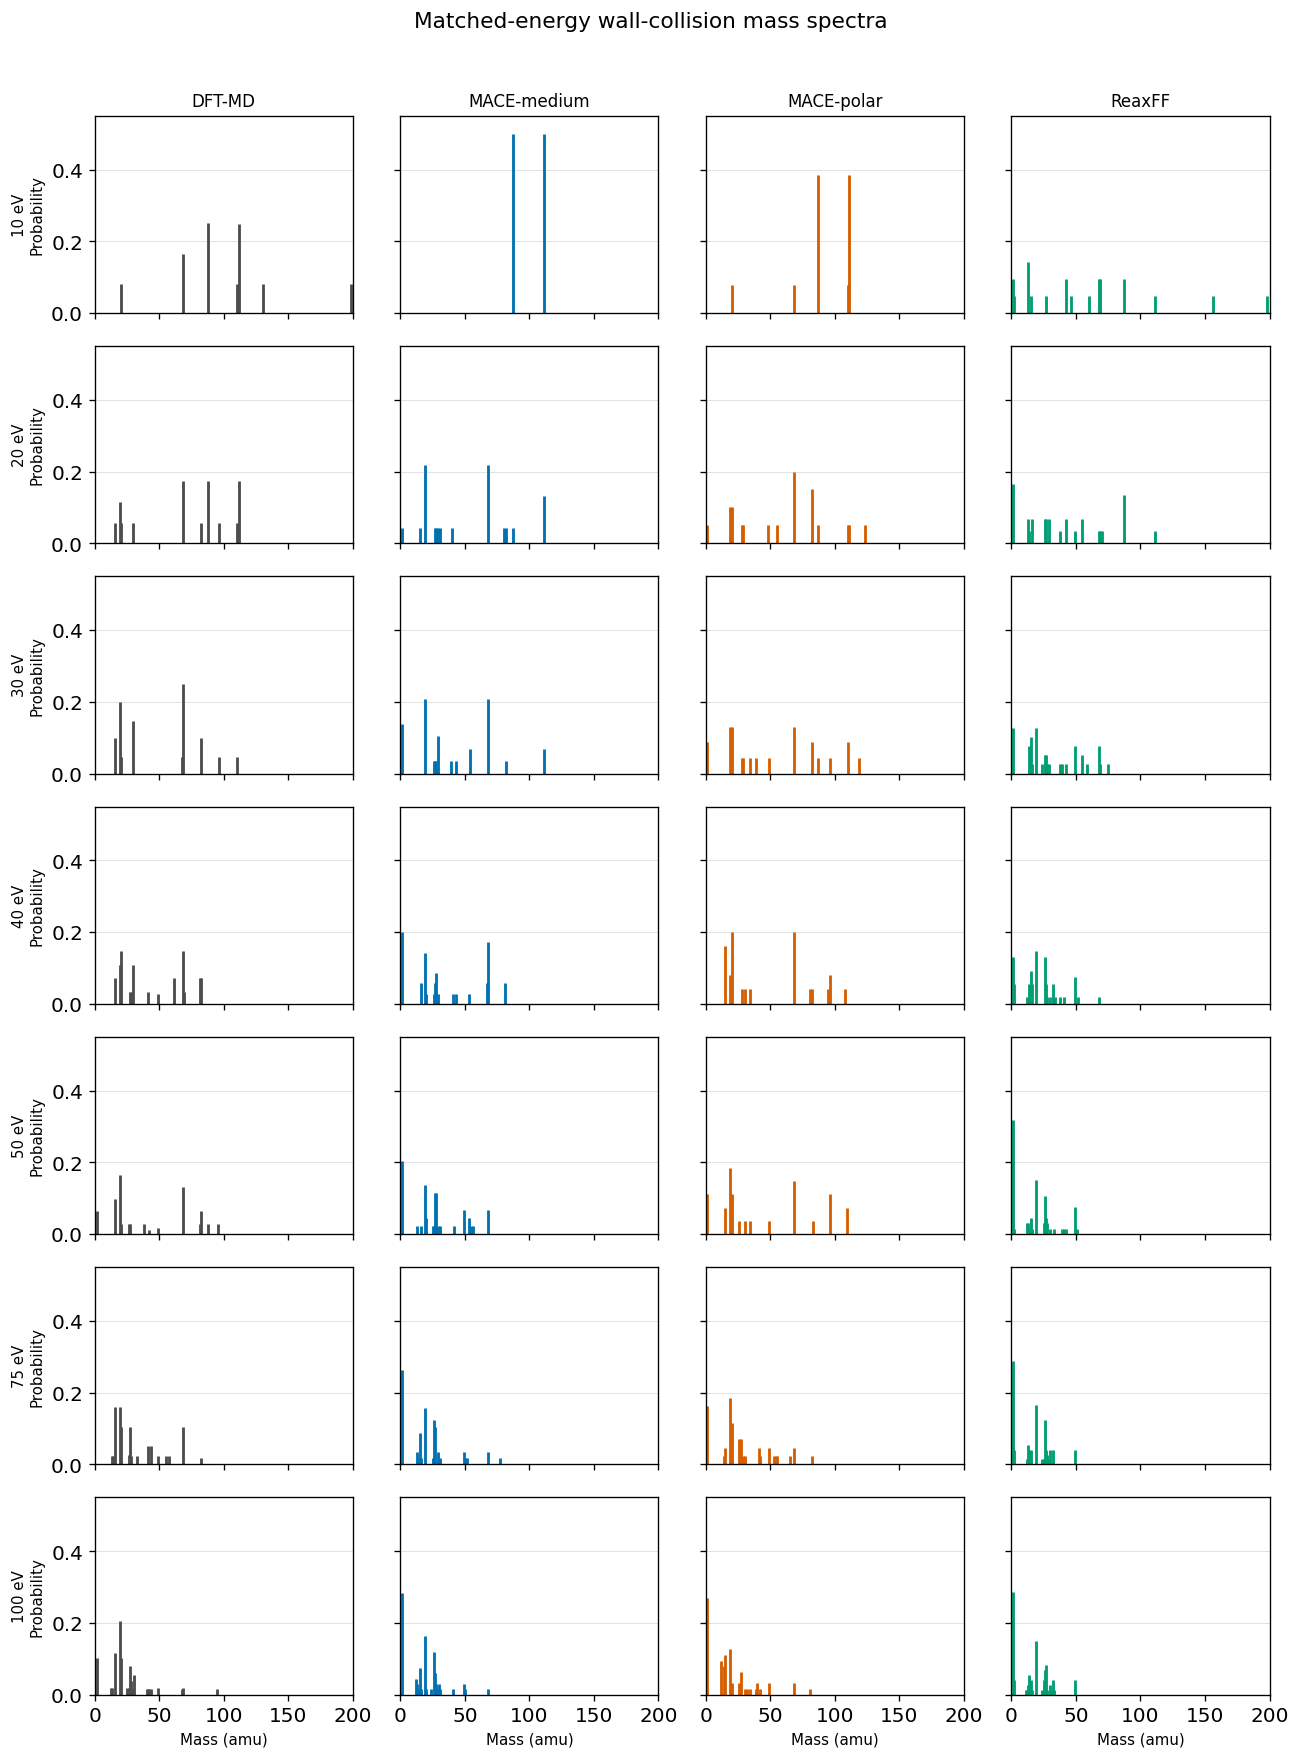

In [3]:
methods = ['DFT-MD', 'MACE-medium', 'MACE-polar', 'ReaxFF']
energies = [10, 20, 30, 40, 50, 75, 100]
colors = {
    'DFT-MD': '#4D4D4D',
    'MACE-medium': '#0072B2',
    'MACE-polar': '#D55E00',
    'ReaxFF': '#009E73',
}

fig, axes = plt.subplots(len(energies), len(methods), figsize=(11.0, 14.5), sharex=True, sharey=True)
for row, energy in enumerate(energies):
    for col, method in enumerate(methods):
        ax = axes[row, col]
        subset = spectra[(spectra.method == method) & (spectra.energy_eV == energy)]
        ax.vlines(subset.mass_amu, 0, subset.probability, color=colors[method], linewidth=1.7)
        ax.set_xlim(0, 200)
        ax.set_ylim(0, 0.55)
        ax.grid(axis='y', color='#DDDDDD', linewidth=0.5)
        if row == 0:
            title = method
            ax.set_title(title)
        if col == 0:
            ax.set_ylabel(f'{energy} eV\nProbability')
        if row == len(energies) - 1:
            ax.set_xlabel('Mass (amu)')

fig.suptitle('Matched-energy wall-collision mass spectra', y=1.01, fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES / 'matched_energy_mass_spectra.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES / 'matched_energy_mass_spectra.pdf', bbox_inches='tight')
plt.show()

## Complete digitized DFT energy series

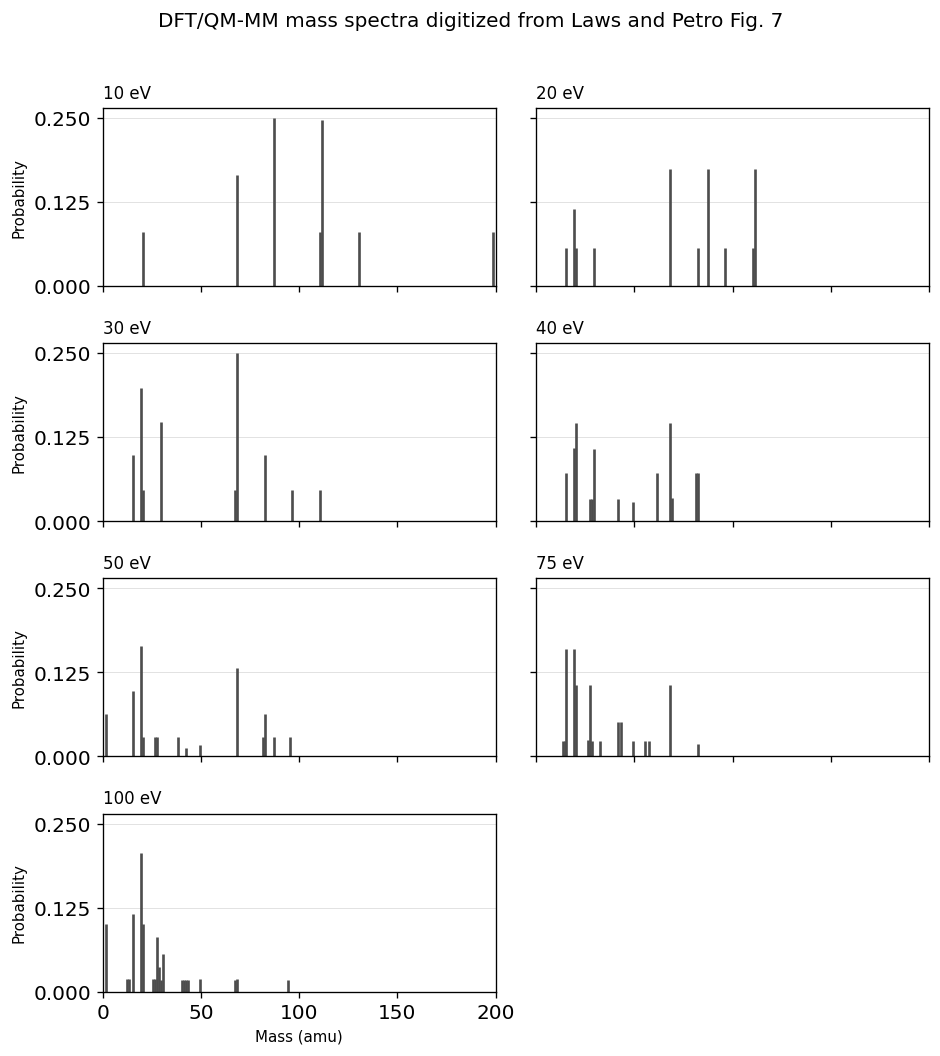

In [4]:
dft_energies = sorted(dft.energy_eV.unique())
fig, axes = plt.subplots(4, 2, figsize=(8.0, 8.7), sharex=True, sharey=True)
for ax, energy in zip(axes.ravel(), dft_energies):
    subset = dft[dft.energy_eV == energy]
    ax.vlines(subset.mass_amu, 0, subset.probability, color=colors['DFT-MD'], linewidth=1.6)
    ax.set_title(f'{energy:g} eV', loc='left')
    ax.set_xlim(0, 200)
    ax.set_ylim(0, 0.265)
    ax.set_yticks([0, 0.125, 0.250])
    ax.grid(axis='y', color='#DDDDDD', linewidth=0.5)
axes.ravel()[-1].axis('off')
for ax in axes[:, 0]:
    ax.set_ylabel('Probability')
for ax in axes[-1, :]:
    if ax.axison:
        ax.set_xlabel('Mass (amu)')
fig.suptitle('DFT/QM-MM mass spectra digitized from Laws and Petro Fig. 7', y=1.01, fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES / 'dft_digitized_all_energies.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES / 'dft_digitized_all_energies.pdf', bbox_inches='tight')
plt.show()

## MACE covalent-breakup fractions

Points are the fractions over six orientations per model-energy condition; error bars are 95% Wilson intervals.

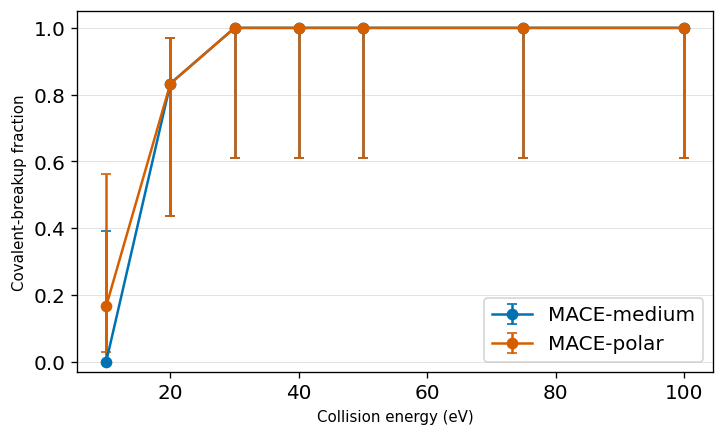

,model,energy_eV,n_cases,covalent_breakup_cases,covalent_breakup_fraction,covalent_breakup_wilson_low,covalent_breakup_wilson_high,ionic_dissociation_cases,ionic_dissociation_fraction,mean_final_fragment_count,median_simulated_time_fs,mean_elapsed_time_sec
0,MACE-medium,10.0,6,0,0.000000,0.000000,0.390343,6,1.000000,2.000000,2000.00,NaN
1,MACE-medium,20.0,6,5,0.833333,0.436491,0.969947,5,0.833333,3.833333,2000.00,NaN
2,MACE-medium,30.0,6,6,1.000000,0.609657,1.000000,6,1.000000,4.833333,2000.00,NaN
3,MACE-medium,40.0,6,6,1.000000,0.609657,1.000000,6,1.000000,5.833333,2000.00,NaN
4,MACE-medium,50.0,6,6,1.000000,0.609657,1.000000,6,1.000000,7.333333,2000.00,NaN
5,MACE-medium,75.0,6,6,1.000000,0.609657,1.000000,6,1.000000,9.500000,2000.00,NaN
6,MACE-medium,100.0,6,6,1.000000,0.609657,1.000000,6,1.000000,11.166667,2000.00,NaN
7,MACE-polar,10.0,6,1,0.166667,0.030053,0.563509,0,0.000000,2.166667,1000.00,157.544777
8,MACE-polar,20.0,6,5,0.833333,0.436491,0.969947,6,1.000000,3.333333,1000.00,508.974315
9,MACE-polar,30.0,6,6,1.000000,0.609657,1.000000,6,1.000000,3.833333,1000.00,675.083356


In [5]:
outcomes = pd.read_csv(DATA / 'processed' / 'wall_by_energy.csv')
fig, ax = plt.subplots(figsize=(6.2, 3.8))
for method in ['MACE-medium', 'MACE-polar']:
    group = outcomes[outcomes.model == method].sort_values('energy_eV')
    y = group.covalent_breakup_fraction.to_numpy()
    lower = y - group.covalent_breakup_wilson_low.to_numpy()
    upper = group.covalent_breakup_wilson_high.to_numpy() - y
    ax.errorbar(group.energy_eV, y, yerr=[lower, upper], marker='o', capsize=3,
                linewidth=1.5, color=colors[method], label=method)
ax.set(xlabel='Collision energy (eV)', ylabel='Covalent-breakup fraction', ylim=(-0.03, 1.05))
ax.grid(axis='y', color='#DDDDDD', linewidth=0.5)
ax.legend(fontsize = 12)
fig.tight_layout()
fig.savefig(FIGURES / 'mace_breakup_fraction.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES / 'mace_breakup_fraction.pdf', bbox_inches='tight')
plt.show()
display(outcomes)

## Runtime benchmark

The DFT value is paper-reported. MACE values are projected from measured force-evaluation timing for 4000 steps. The ReaxFF paper does not report per-trajectory runtime or memory.

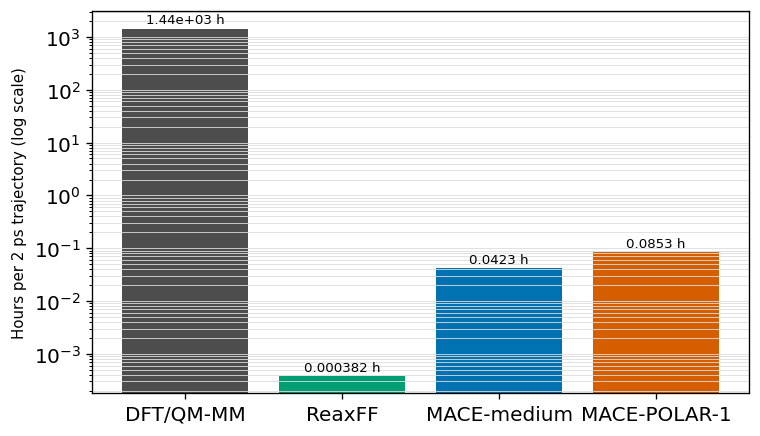

,method,wall_time_hours_per_2ps_trajectory,memory_GB,memory_type,hardware,basis,source
0,DFT/QM-MM,1440.000000,128.00000,reported host memory,16 CPU cores,reported maximum wall time for microcanonical ...,"Laws and Petro 2026, Sec. II.A, p. 113302-4"
1,ReaxFF,0.000382,0.01443,"LAMMPS per-rank allocation, not total process RSS","1 CPU thread, Intel i9-13900K",measured mean of 42 DFT-matched 4000-step traj...,local benchmark 2026-07-03
2,MACE-medium,0.042300,1.01800,measured peak PyTorch GPU allocation,NVIDIA RTX 4090,projected from median 0.0381 s force evaluatio...,local benchmark 2026-07-02
3,MACE-POLAR-1,0.085300,0.37100,measured peak PyTorch GPU allocation,NVIDIA RTX 4090,projected from median 0.0768 s force evaluatio...,local benchmark 2026-07-02


In [6]:
benchmark = pd.read_csv(DATA / 'benchmarks' / 'resource_benchmark.csv')
runtime = benchmark.dropna(subset=['wall_time_hours_per_2ps_trajectory']).copy()

fig, ax = plt.subplots(figsize=(6.5, 3.8))
bar_colors = [colors.get(name.replace('DFT/QM-MM', 'DFT-MD').replace('MACE-POLAR-1', 'MACE-polar'), '#777777')
              for name in runtime.method]
ax.bar(runtime.method, runtime.wall_time_hours_per_2ps_trajectory, color=bar_colors)
ax.set_yscale('log')
ax.set_ylabel('Hours per 2 ps trajectory (log scale)')
ax.grid(axis='y', color='#DDDDDD', linewidth=0.5, which='both')
for index, value in enumerate(runtime.wall_time_hours_per_2ps_trajectory):
    ax.text(index, value * 1.25, f'{value:.3g} h', ha='center', fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / 'runtime_benchmark.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES / 'runtime_benchmark.pdf', bbox_inches='tight')
plt.show()
display(benchmark)

In [7]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.legend as lg
import matplotlib.ticker as ticker
from scipy import interpolate
from matplotlib.ticker import LogFormatterSciNotation 
import matplotlib as mpl
import os, sys
import pandas as pd 
import matplotlib.style
import matplotlib.patches as patches


import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times", "Nimbus Roman", "DejaVu Serif"],
})


mpl.rcParams['font.size'] = 23
mpl.rcParams["font.weight"] = "bold"
# mpl.rcParams['font.family'] = 'Georgia'
mpl.rcParams['legend.fontsize'] = 23
mpl.rcParams['axes.linewidth'] = 3.0
mpl.rcParams['lines.linewidth'] = 3.0
mpl.rcParams['axes.labelweight'] = "bold"
mpl.rcParams['axes.titleweight'] = "bold"
mpl.rcParams['xtick.major.size'] = 8
mpl.rcParams['xtick.top']=True
mpl.rcParams['ytick.right']=True
mpl.rcParams['xtick.minor.size'] = 4
mpl.rcParams['xtick.major.width'] = 2
mpl.rcParams['xtick.minor.width'] = 1.5
mpl.rcParams['xtick.direction'] = "in"
mpl.rcParams['ytick.major.size'] = 8
mpl.rcParams['ytick.minor.size'] = 4
mpl.rcParams['ytick.major.width'] = 2
mpl.rcParams['ytick.minor.width'] = 1
mpl.rcParams['ytick.direction'] = "in"
mpl.rcParams['xtick.major.top'] = True
mpl.rcParams['xtick.minor.top'] = True
mpl.rcParams['ytick.major.right'] = True
mpl.rcParams['ytick.minor.right'] = True

## Interpretation

The digitized DFT panels provide approximate numerical peak positions and heights. The complete ReaxFF rerun uses the same seven energies, six Cartesian dipole incidence vectors, and 2 ps endpoint as DFT. ReaxFF predicts much earlier and broader fragmentation, including extensive light products at 10-20 eV. This is a direct case-matrix comparison, not an identical-Hamiltonian comparison: the initial structures, electronic treatment, timestep, and surface models remain method-specific. MACE-medium also retains an atomistic Au slab but uses a different historical orientation set; MACE-polar uses the six Cartesian directions with a repulsive wall.

## HF formation audit

Exact HF components were tracked in every stored MACE and ReaxFF frame. The DFT series is digitized from the published spectrum and is shown separately because its ordinate is not a case fraction.

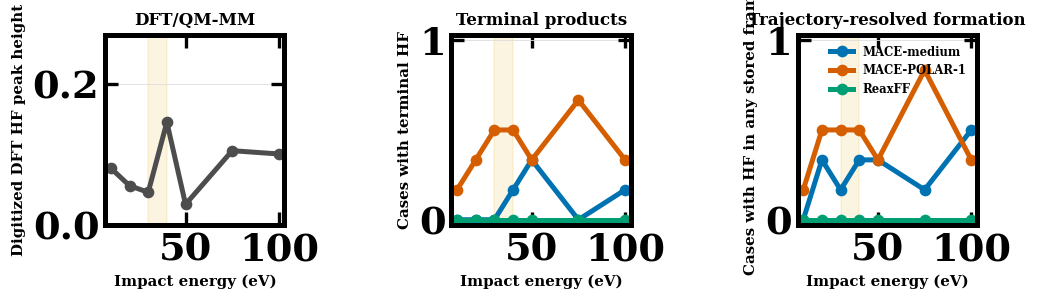

,energy_eV,DFT_HF_reported,DFT_digitized_HF_mass_amu,DFT_digitized_HF_peak_height,MACE_medium_any_HF_cases,MACE_medium_terminal_HF_cases,MACE_medium_n_cases,MACE_polar_any_HF_cases,MACE_polar_terminal_HF_cases,MACE_polar_n_cases,ReaxFF_any_HF_cases,ReaxFF_terminal_HF_cases,ReaxFF_n_cases
0,10,True,20.339,0.08075,0,0,6,1,1,6,0,0,6
1,20,True,20.339,0.05590,2,0,6,3,2,6,0,0,6
2,30,True,20.339,0.04658,1,0,6,3,3,6,0,0,6
3,40,True,20.339,0.14596,2,1,6,3,3,6,0,0,6
4,50,True,20.339,0.02950,2,2,6,2,2,6,0,0,6
5,75,True,20.339,0.10559,1,0,6,5,4,6,0,0,6
6,100,True,20.339,0.10093,3,1,6,2,2,6,0,0,6


,evidence_source,HF_result,electronic_or_charge_model,surface,evidence_strength,main_limitation
0,Laws and Petro DFT/QM-MM,HF peak reported at every 10-100 eV panel; BF4...,spin-unrestricted DFT with time-dependent RESP...,frozen 2000-atom Au slab,mechanistic simulation; 6 orientations per ene...,small deterministic ensemble and no author-sup...
1,Bendimerad and Petro published ReaxFF,HF not labeled; authors state the fate of free...,ReaxFF with QEq; no explicit electronic states,fixed continuum LJ 12-6 wall,large orientation ensemble and published pseud...,force field lacks Au and was validated for a d...
2,DFT-matched ReaxFF rerun,0/42 trajectories contain an exact HF componen...,same ReaxFF/QEq parameterization as source rep...,fixed continuum LJ 12-6 wall,complete trajectories on the DFT 7-energy x 6-...,50 fs output interval may miss very short-live...
3,MACE-medium,HF appears in 4/42 terminal states and 11/42 t...,short-range transferable MACE foundation model,frozen 256-atom Au slab plus pair-specific LJ,2 ps trajectories with 5 fs output,orientation set differs from DFT and molecule-...
4,MACE-POLAR-1,HF appears in 17/42 terminal states and 19/42 ...,polarizable long-range model with charge equil...,harmonic repulsive wall,explicit stored-frame HF pathway across the DF...,up to 1 ps with early stopping; no explicit Au...
5,Facility RGA evidence cited by Laws and Petro,neutral HF detected and assigned to EMI-BF4 ->...,experiment,electrospray facility surfaces,independent neutral-species measurement,"not a controlled single-collision, energy- and..."


In [8]:
hf = pd.read_csv(DATA / 'processed' / 'hf_energy_summary.csv')
hf_comparison = pd.read_csv(DATA / 'processed' / 'hf_cross_method_comparison.csv')

hf_colors = {'MACE-medium': '#0072B2', 'MACE-polar': '#D55E00', 'ReaxFF': '#009E73'}
fig, axes = plt.subplots(1, 3, figsize=(9.0, 3.0))
axes[0].plot(
    hf_comparison.energy_eV,
    hf_comparison.DFT_digitized_HF_peak_height,
    marker='o',
    color='#4D4D4D',
)
axes[0].set(ylabel='Digitized DFT HF peak height', title='DFT/QM-MM', ylim=(0, 0.27))

for model, color in hf_colors.items():
    group = hf[hf.model == model].sort_values('energy_eV')
    label = model.replace('MACE-polar', 'MACE-POLAR-1')
    axes[1].plot(group.energy_eV, group.terminal_HF_case_fraction,
                 marker='o', color=color, label=label)
    axes[2].plot(group.energy_eV, group.HF_case_fraction,
                 marker='o', color=color, label=label)
axes[1].set(ylabel='Cases with terminal HF', title='Terminal products', ylim=(-0.03, 1.03))
axes[2].set(ylabel='Cases with HF in any stored frame',
            title='Trajectory-resolved formation', ylim=(-0.03, 1.03))
axes[2].legend(frameon=False, fontsize=7)
for ax in axes:
    ax.axvspan(30, 40, color='#E6AB02', alpha=0.12)
    ax.set(xlabel='Impact energy (eV)', xlim=(7, 103))
    ax.grid(axis='y', color='#DDDDDD', linewidth=0.5)
fig.tight_layout()
fig.savefig(FIGURES / 'hf_cross_method_comparison.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES / 'hf_cross_method_comparison.pdf', bbox_inches='tight')
plt.show()

display(hf_comparison)
display(pd.read_csv(DATA / 'literature' / 'hf_evidence_review.csv'))